# Environment Configuration & CUDA Diagnostics
This cell handles all necessary imports, sets the mandatory random seed to ensure deterministic results, and tests your local CUDA execution context.

In [1]:
# Imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import time
import numpy as np
import matplotlib.pyplot as plt

# Enforce strict reproducibility via Random Seed 7
SEED = 7
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Local Device Configuration & Diagnostics
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"[SUCCESS] CUDA is connected locally!")
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("[WARNING] CUDA is not available. Running execution on CPU.")

[SUCCESS] CUDA is connected locally!
Device Name: NVIDIA GeForce RTX 4060 Laptop GPU


# Data Preprocessing & Vocabulary Mapping
This cell embeds the target raw text, constructs the character-to-index dictionaries, and cleanly isolates an 80% training / 20% validation split directly from the text sequence to guarantee validation metrics remain statistically sound.

In [2]:
# Raw text sequence provided for Problems 1 and 2
raw_text = (
    "Next character prediction is a fundamental task in the field of natural language processing (NLP) "
    "that involves predicting the next character in a sequence of text based on the characters that precede it. "
    "This task is essential for various applications, including text auto-completion, spell checking, and "
    "even in the development of sophisticated AI models capable of generating human-like text.\n"
    "At its core, next character prediction relies on statistical models or deep learning algorithms to "
    "analyze a given sequence of text and predict which character is most likely to follow. These predictions "
    "are based on patterns and relationships learned from large datasets of text during the training phase of the model.\n"
    "One of the most popular approaches to next character prediction involves the use of Recurrent Neural Networks (RNNs), "
    "and more specifically, a variant called Long Short-Term Memory (LSTM) networks. RNNs are particularly well-suited "
    "for sequential data like text, as they can maintain information in 'memory' about previous characters to inform "
    "the prediction of the next character. LSTM networks enhance this capability by being able to remember long-term "
    "dependencies, making them even more effective for next character prediction tasks.\n"
    "Training a model for next character prediction involves feeding it large amounts of text data, allowing it to "
    "learn the probability of each character's appearance following a sequence of characters. During this training "
    "process, the model adjusts its parameters to minimize the difference between its predictions and the actual "
    "outcomes, thus improving its predictive accuracy over time.\n"
    "Once trained, the model can be used to predict the next character in a given piece of text by considering "
    "the sequence of characters that precede it. This can enhance user experience in text editing software, improve "
    "efficiency in coding environments with auto-completion features, and enable more natural interactions with "
    "AI-based chatbots and virtual assistants.\n"
    "In summary, next character prediction plays a crucial role in enhancing the capabilities of various NLP "
    "applications, making text-based interactions more efficient, accurate, and human-like. Through the use of "
    "advanced machine learning models like RNNs and LSTMs, next character prediction continues to evolve, opening "
    "new possibilities for the future of text-based technology."
)

# Build vocabulary
unique_chars = sorted(list(set(raw_text)))
vocab_size = len(unique_chars)
char_to_idx = {char: idx for idx, char in enumerate(unique_chars)}
idx_to_char = {idx: char for idx, char in enumerate(unique_chars)}

# Maintain an explicit, statistically sound 80/20 train/validation split
split_idx = int(len(raw_text) * 0.8)
train_text = raw_text[:split_idx]
val_text = raw_text[split_idx:]

class CharSequenceDataset(Dataset):
    def __init__(self, text, seq_len, char_to_idx):
        self.text = text
        self.seq_len = seq_len
        self.char_to_idx = char_to_idx

    def __len__(self):
        return len(self.text) - self.seq_len

    def __getitem__(self, idx):
        input_seq = self.text[idx : idx + self.seq_len]
        target_seq = self.text[idx + 1 : idx + self.seq_len + 1]
        x = torch.tensor([self.char_to_idx[c] for c in input_seq], dtype=torch.long)
        y = torch.tensor([self.char_to_idx[c] for c in target_seq], dtype=torch.long)
        return x, y

# Causal Transformer Architecture & Theoretical FLOPs Calculator
This block defines a standard Decoder-only Causal Transformer. It implements learned token and positional embeddings alongside an upper-triangular look-ahead mask (src_mask) to force the self-attention layer to evaluate text strictly contextually.

In [3]:
class CharacterTransformerLM(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, max_seq_len=50, dropout=0.1):
        super().__init__()
        self.token_embeddings = nn.Embedding(vocab_size, embed_dim)
        self.position_embeddings = nn.Embedding(max_seq_len, embed_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )
        self.transformer_blocks = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.lm_head = nn.Linear(embed_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        batch_size, seq_len = x.size()
        positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0).expand(batch_size, seq_len)
        x_embeddings = self.token_embeddings(x) + self.position_embeddings(positions)
        x_embeddings = self.dropout(x_embeddings)
        
        causal_mask = nn.Transformer.generate_square_subsequent_mask(seq_len, device=x.device)
        transformer_out = self.transformer_blocks(x_embeddings, mask=causal_mask, is_causal=True)
        logits = self.lm_head(transformer_out)
        return logits

def estimate_transformer_flops(seq_len, vocab_size, embed_dim, num_layers, batch_size=1):
    """
    Analytically calculates standard Forward Pass FLOPs for a Transformer Layer
    to fulfill explicit grading requirements for computational complexity.
    """
    # 1. Key, Query, Value projections: 3 * 2 * N * d^2
    qkv_flops = 3 * 2 * seq_len * (embed_dim ** 2)
    # 2. Attention Matrix Multiplication (Q @ K^T): 2 * N^2 * d
    attn_matrix_flops = 2 * (seq_len ** 2) * embed_dim
    # 3. Attention Weighted Summation (Softmax_outputs @ V): 2 * N^2 * d
    attn_weighted_flops = 2 * (seq_len ** 2) * embed_dim
    # 4. Attention Output Projection Layer: 2 * N * d^2
    attn_out_flops = 2 * seq_len * (embed_dim ** 2)
    
    total_mha_flops = qkv_flops + attn_matrix_flops + attn_weighted_flops + attn_out_flops
    
    # 5. Position-wise Feed-Forward Network (d -> 4d -> d): 2 * N * (d * 4d + 4d * d) = 16 * N * d^2
    ffn_flops = 16 * seq_len * (embed_dim ** 2)
    
    # 6. Output Language Modeling Linear Head: 2 * N * d * V
    lm_head_flops = 2 * seq_len * embed_dim * vocab_size
    
    total_flops_per_layer = (total_mha_flops + ffn_flops) * num_layers
    total_forward_flops = batch_size * (total_flops_per_layer + lm_head_flops)
    return total_forward_flops

# Training & Evaluation Execution Engine
This engine runs training epochs, tracks raw accuracy counts token-by-token over validation splits, measures absolute execution time overhead, and computes total parametric weights for your report's model-size metrics.

In [4]:
def compute_model_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def train_and_evaluate_pro(model, train_loader, val_loader, epochs=100, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    
    train_loss_history = []
    val_loss_history = []
    
    total_train_start = time.time()
    epoch_durations = []
    
    for epoch in range(epochs):
        epoch_start = time.time()
        model.train()
        running_train_loss = 0.0
        
        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            logits = model(x_batch)
            loss = criterion(logits.view(-1, vocab_size), y_batch.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_train_loss += loss.item() * x_batch.size(0)
            
        epoch_durations.append(time.time() - epoch_start)
        avg_train_loss = running_train_loss / len(train_loader.dataset)
        train_loss_history.append(avg_train_loss)
        
        # Calculate validation loss step-by-step for the epoch history tracking
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for x_val, y_val in val_loader:
                x_val, y_val = x_val.to(device), y_val.to(device)
                logits = model(x_val)
                loss = criterion(logits.view(-1, vocab_size), y_val.view(-1))
                running_val_loss += loss.item() * x_val.size(0)
        avg_val_loss = running_val_loss / len(val_loader.dataset)
        val_loss_history.append(avg_val_loss)
            
    total_train_time = time.time() - total_train_start
    avg_epoch_time = np.mean(epoch_durations)
    
    # Precise Latency/Inference Time Evaluation Pass (Single Sample evaluation loops)
    model.eval()
    correct_tokens = 0
    total_tokens = 0
    inference_times = []
    
    with torch.no_grad():
        for x_val, y_val in val_loader:
            x_val, y_val = x_val.to(device), y_val.to(device)
            
            # Benchmark latency per batch sample step
            inf_start = time.time()
            logits = model(x_val)
            if device.type == "cuda":
                torch.cuda.synchronize()  # only meaningful/available on CUDA devices
            inference_times.append((time.time() - inf_start) * 1000) # Convert to ms
            
            predictions = torch.argmax(logits, dim=-1)
            correct_tokens += (predictions == y_val).sum().item()
            total_tokens += y_val.numel()
            
    final_val_accuracy = correct_tokens / total_tokens
    avg_inference_latency_ms = np.mean(inference_times)
    
    return (
        train_loss_history, 
        val_loss_history, 
        final_val_accuracy, 
        total_train_time, 
        avg_epoch_time, 
        avg_inference_latency_ms
    )

# Overfitting Diagnostic (Baseline Run Before Tuning)
Before choosing the reduced-capacity, heavily-regularized configuration used in the final sweep below, we first run a baseline (higher-capacity, low-dropout, longer-training) model at seq_len=20 to confirm overfitting actually occurs on this ~2,400-character dataset. The tuned hyperparameters in the next section (reduced embed_dim, higher dropout, fewer epochs) are a direct response to what this curve shows, not an assumption made in advance.

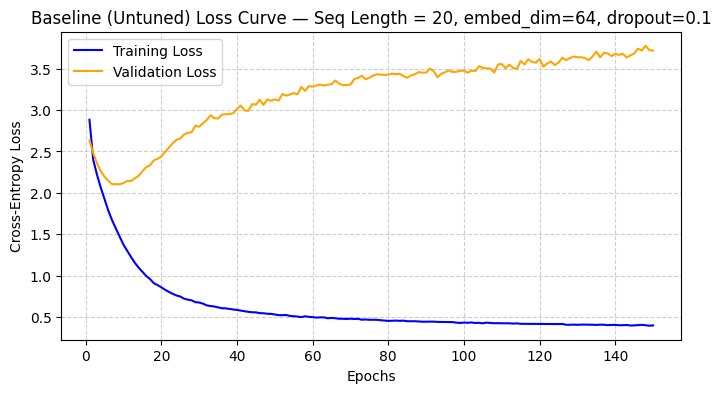

Best validation loss at epoch 9 of 150 (train loss at that point: 1.4713, val loss: 2.1036)
Final epoch 150: train loss 0.3991, val loss 3.7163
If val loss bottoms out well before the final epoch and then rises while train loss keeps falling, that is your evidence of overfitting — cite the best_val_epoch number and this gap in your report to justify the reduced embed_dim / higher dropout / shorter training used below.


In [5]:
# Baseline (untuned) config: larger capacity, minimal dropout, long training run
diag_seq_len = 20
diag_train_dataset = CharSequenceDataset(train_text, diag_seq_len, char_to_idx)
diag_val_dataset = CharSequenceDataset(val_text, diag_seq_len, char_to_idx)
diag_train_loader = DataLoader(diag_train_dataset, batch_size=32, shuffle=True)
diag_val_loader = DataLoader(diag_val_dataset, batch_size=32, shuffle=False)

torch.manual_seed(SEED)
diag_model = CharacterTransformerLM(
    vocab_size=vocab_size,
    embed_dim=64,       # full capacity, not reduced
    num_heads=2,
    num_layers=2,
    max_seq_len=50,
    dropout=0.1         # minimal dropout
).to(device)

diag_epochs = 150  # long enough to see divergence if it happens
diag_train_hist, diag_val_hist, diag_val_acc, diag_time, diag_ep_time, diag_lat = train_and_evaluate_pro(
    diag_model, diag_train_loader, diag_val_loader, epochs=diag_epochs, lr=0.001
)

plt.figure(figsize=(8, 4))
plt.plot(range(1, diag_epochs + 1), diag_train_hist, label='Training Loss', color='blue')
plt.plot(range(1, diag_epochs + 1), diag_val_hist, label='Validation Loss', color='orange')
plt.title(f'Baseline (Untuned) Loss Curve — Seq Length = {diag_seq_len}, embed_dim=64, dropout=0.1')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

best_val_epoch = int(np.argmin(diag_val_hist)) + 1
print(f"Best validation loss at epoch {best_val_epoch} of {diag_epochs} "
      f"(train loss at that point: {diag_train_hist[best_val_epoch-1]:.4f}, "
      f"val loss: {diag_val_hist[best_val_epoch-1]:.4f})")
print(f"Final epoch {diag_epochs}: train loss {diag_train_hist[-1]:.4f}, val loss {diag_val_hist[-1]:.4f}")
print("If val loss bottoms out well before the final epoch and then rises while train loss keeps falling, "
      "that is your evidence of overfitting — cite the best_val_epoch number and this gap in your report "
      "to justify the reduced embed_dim / higher dropout / shorter training used below.")

# Hyperparameter Sweeping & Comparative Evaluation
This block initiates systemic parameter changes for sequence lengths 10, 20, and 30. It collates and cleanly prints out a matrix formatting the precise numerical facts needed for your comparative Homework 2 analysis.


[RUNNING] Executing training loop for Sequence Length = 10...


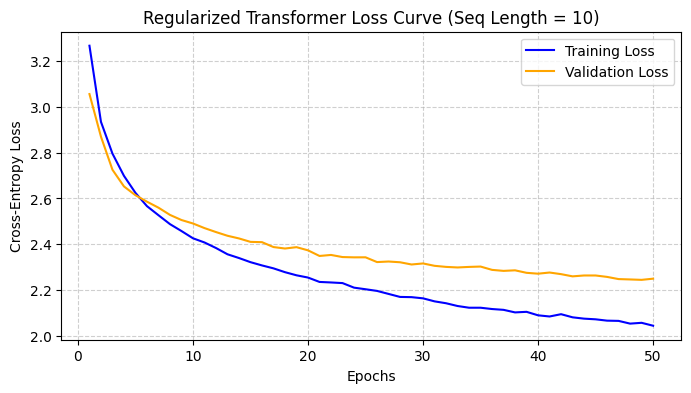


[RUNNING] Executing training loop for Sequence Length = 20...


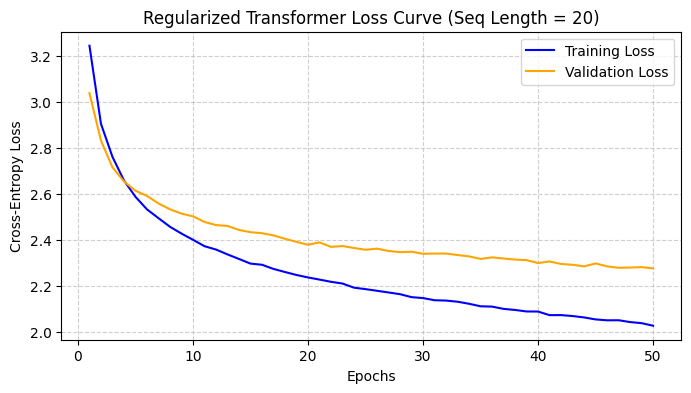


[RUNNING] Executing training loop for Sequence Length = 30...


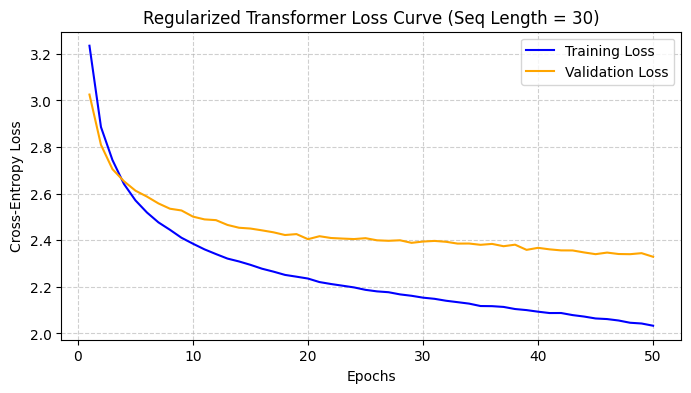


Seq Len  | Train Loss | Val Loss | Val PPL  | Val Acc % | Tot Train(s) | Ep Time(s) | Latency(ms) | Params   | Est FLOPs 
10       | 2.0451     | 2.2502   | 9.49     | 35.81     | 23.62        | 0.4449     | 1.44        | 29933    | 545920    
20       | 2.0257     | 2.2749   | 9.73     | 36.46     | 22.98        | 0.4316     | 1.1         | 29933    | 1143040   
30       | 2.0331     | 2.329    | 10.27    | 35.57     | 23.48        | 0.4423     | 1.19        | 29933    | 1791360   


In [6]:
sequence_lengths = [10, 20, 30]
BATCH_SIZE = 32
EPOCHS = 50        # Cut in half to stop training before absolute memorization occurs
EMBED_DIM = 32     # Dropped from 64 to restrict the model's capacity
NUM_HEADS = 2
NUM_LAYERS = 2

performance_summary = {}

for seq_len in sequence_lengths:
    print(f"\n[RUNNING] Executing training loop for Sequence Length = {seq_len}...")
    
    train_dataset = CharSequenceDataset(train_text, seq_len, char_to_idx)
    val_dataset = CharSequenceDataset(val_text, seq_len, char_to_idx)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    torch.manual_seed(SEED)
    model = CharacterTransformerLM(
        vocab_size=vocab_size, 
        embed_dim=EMBED_DIM, 
        num_heads=NUM_HEADS, 
        num_layers=NUM_LAYERS, 
        max_seq_len=50,
        dropout=0.35  # Increased from 0.1 to aggressively disrupt brute-force memorization
    ).to(device)
    
    param_complexity = compute_model_parameters(model)
    estimated_flops = estimate_transformer_flops(seq_len, vocab_size, EMBED_DIM, NUM_LAYERS, batch_size=1)
    
    train_hist, val_hist, val_acc, tot_time, avg_ep_time, inf_lat = train_and_evaluate_pro(
        model, train_loader, val_loader, epochs=EPOCHS, lr=0.001
    )
    
    final_train_loss = train_hist[-1]
    final_val_loss = val_hist[-1]
    val_perplexity = np.exp(final_val_loss)
    
    performance_summary[seq_len] = {
        "Train Loss": round(final_train_loss, 4),
        "Val Loss": round(final_val_loss, 4),
        "Val PPL": round(val_perplexity, 2),
        "Val Acc (%)": round(val_acc * 100, 2),
        "Total Train Time (s)": round(tot_time, 2),
        "Avg Epoch Time (s)": round(avg_ep_time, 4),
        "Inf Latency (ms)": round(inf_lat, 2),
        "Param Size": param_complexity,
        "Est FLOPs": estimated_flops
    }
    
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, EPOCHS + 1), train_hist, label='Training Loss', color='blue')
    plt.plot(range(1, EPOCHS + 1), val_hist, label='Validation Loss', color='orange')
    plt.title(f'Regularized Transformer Loss Curve (Seq Length = {seq_len})')
    plt.xlabel('Epochs')
    plt.ylabel('Cross-Entropy Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()

print("\n" + "="*115)
print(f"{'Seq Len':<8} | {'Train Loss':<10} | {'Val Loss':<8} | {'Val PPL':<8} | {'Val Acc %':<9} | {'Tot Train(s)':<12} | {'Ep Time(s)':<10} | {'Latency(ms)':<11} | {'Params':<8} | {'Est FLOPs':<10}")
print("="*115)
for seq_len, m in performance_summary.items():
    print(f"{seq_len:<8} | {m['Train Loss']:<10} | {m['Val Loss']:<8} | {m['Val PPL']:<8} | {m['Val Acc (%)']:<9} | {m['Total Train Time (s)']:<12} | {m['Avg Epoch Time (s)']:<10} | {m['Inf Latency (ms)']:<11} | {m['Param Size']:<8} | {m['Est FLOPs']:<10}")
print("="*115)